# Customer Churn Prediction Model Development

This notebook focuses on building machine learning models for customer churn prediction.

Objectives:

- Load the final processed dataset
- Prepare features and target variable
- Split data into training and testing sets
- Apply feature scaling
- Handle class imbalance
- Train multiple machine learning models
- Compare model performance
- Perform hyperparameter tuning
- Select the best model
- Save the final model for deployment

In [5]:
# Import required libraries

import pandas as pd
import numpy as np

# Model building
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option("display.max_columns", None)

## Load Final Dataset

The final cleaned dataset generated during preprocessing and outlier analysis is loaded for model development.

In [6]:
# Load dataset

df = pd.read_csv(
    "../data/final_telco_churn.csv"
)

# Display shape

print("Dataset Shape:", df.shape)

# Display first rows

df.head()

Dataset Shape: (7043, 37)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AverageMonthlySpend,HighValueCustomer,LongTermCustomer,TenureGroup_Growing,TenureGroup_Established,TenureGroup_Loyal
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,14.925000,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,53.985714,0,1,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,36.050000,0,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,40.016304,0,1,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,50.550000,1,0,0,0,0


In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

### Observation

The final dataset has been loaded successfully.

The dataset contains cleaned, encoded, and engineered features ready for machine learning model development.

The target variable is Churn.

## Feature and Target Separation

Machine learning models require separating input features from the target variable.

Features (X) are used for prediction.

Target (y) contains the churn labels to be predicted.

In [8]:
# Separate features and target

X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7043, 36)
Target Shape: (7043,)


## Target Distribution Analysis

Before model training, the class distribution is examined.

Class imbalance can negatively affect model performance and may require balancing techniques.

In [9]:
# Class distribution

print(y.value_counts())

print("\nPercentage Distribution")

print(
    round(
        y.value_counts(normalize=True)*100,
        2
    )
)

Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage Distribution
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


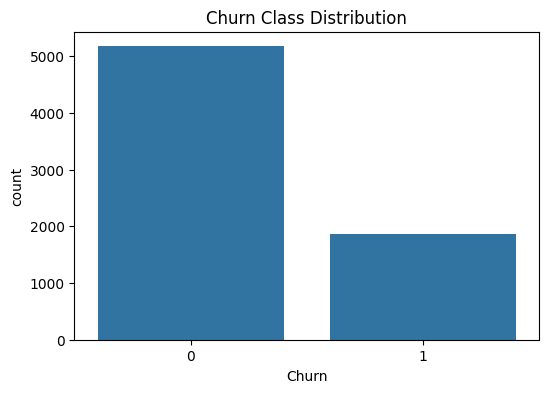

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x=y
)

plt.title("Churn Class Distribution")

plt.show()

## Train Test Split

The dataset is divided into training and testing subsets.

Training data is used for model learning.

Testing data is reserved for unbiased model evaluation.

In [11]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (5634, 36)
Testing Features: (1409, 36)
Training Labels: (5634,)
Testing Labels: (1409,)


In [12]:
print("Training Distribution")

print(
    y_train.value_counts(normalize=True)
)

print("\nTesting Distribution")

print(
    y_test.value_counts(normalize=True)
)

Training Distribution
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Distribution
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Feature Scaling

Numerical features are standardized using StandardScaler.

Scaling ensures that variables with larger magnitudes do not dominate model learning.

In [13]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend"
]

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_test[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AverageMonthlySpend,HighValueCustomer,LongTermCustomer,TenureGroup_Growing,TenureGroup_Established,TenureGroup_Loyal
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.263289,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,-0.236288,0,1,0,1,0
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.504814,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0.182960,1,0,1,0,0
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.751213,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,-0.322843,0,0,1,0,0
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.173699,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,0.159364,1,1,0,1,0
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.990851,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.660445,0,0,0,0,0


# Class Imbalance Handling

The target variable is moderately imbalanced.

To improve minority class prediction performance, SMOTE (Synthetic Minority Oversampling Technique) will be applied to the training dataset only.

The test dataset remains untouched to ensure fair model evaluation.

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
# Create SMOTE object

smote = SMOTE(
    random_state=42
)

# Apply only on training data

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check shapes

print("Original Training Shape:")
print(X_train.shape)

print("\nAfter SMOTE:")
print(X_train_smote.shape)

c:\Users\aateq\anaconda3\envs\myenv\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Original Training Shape:
(5634, 36)

After SMOTE:
(8278, 36)


In [17]:
print(y_train_smote.value_counts())

print("\nPercentage")

print(
    round(
        y_train_smote.value_counts(normalize=True)*100,
        2
    )
)

Churn
0    4139
1    4139
Name: count, dtype: int64

Percentage
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## Observation

SMOTE successfully balanced the training dataset.

The minority churn class was synthetically oversampled to match the majority class.

This helps machine learning algorithms learn churn patterns more effectively.

The test dataset was not modified to maintain realistic performance evaluation.

# Logistic Regression Model

Logistic Regression is used as the baseline classification model.

It is widely used in churn prediction because of its simplicity, interpretability, and strong performance on binary classification problems.

The model will be trained on the SMOTE-balanced training dataset and evaluated on the original test dataset.

In [18]:
# Import logistic regression and evaluation metrics

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [19]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model on SMOTE-balanced data

lr_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate predictions

y_pred_lr = lr_model.predict(X_test)

# Generate probability scores

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [20]:
# Calculate evaluation metrics

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

# Print results

print("Logistic Regression Performance")
print("-" * 40)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC AUC   : {lr_auc:.4f}")

Logistic Regression Performance
----------------------------------------
Accuracy  : 0.7402
Precision : 0.5081
Recall    : 0.6711
F1 Score  : 0.5783
ROC AUC   : 0.8239


In [21]:
# Detailed classification report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.87      0.77      0.81      1035
           1       0.51      0.67      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409



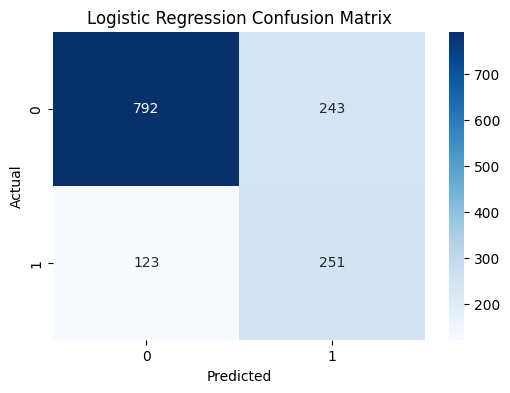

In [22]:
# Plot confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

Logistic Regression was used as the baseline model for customer churn prediction.

Performance metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC were evaluated.

The confusion matrix provides additional insight into the model's ability to correctly identify churn and non-churn customers.

The results from this baseline model will be compared against more advanced machine learning algorithms in subsequent sections.

# Decision Tree Model

Decision Tree is a non-linear machine learning algorithm that learns decision rules from data.

Unlike Logistic Regression, Decision Trees can capture complex relationships and feature interactions.

The model will be trained using the SMOTE-balanced dataset and evaluated on the original test dataset.

In [23]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [24]:
# Create Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train model

dt_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate predictions

y_pred_dt = dt_model.predict(X_test)

# Generate probabilities

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [25]:
# Calculate evaluation metrics

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

# Display results

print("Decision Tree Performance")
print("-"*40)

print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"ROC AUC   : {dt_auc:.4f}")

Decision Tree Performance
----------------------------------------
Accuracy  : 0.7175
Precision : 0.4738
Recall    : 0.5802
F1 Score  : 0.5216
ROC AUC   : 0.6735


In [26]:
# Detailed classification report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1035
           1       0.47      0.58      0.52       374

    accuracy                           0.72      1409
   macro avg       0.65      0.67      0.66      1409
weighted avg       0.74      0.72      0.73      1409



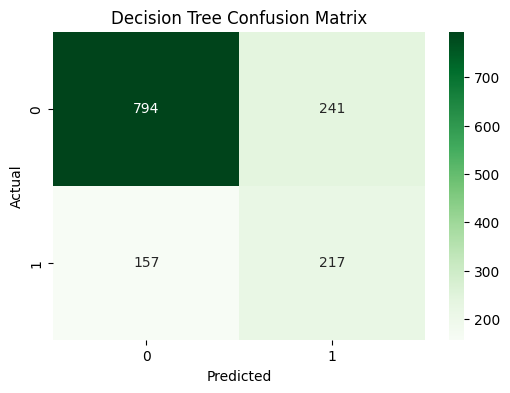

In [27]:
# Create confusion matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
# Extract feature importance

feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": dt_model.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
26,Contract_Two year,0.145062
7,MonthlyCharges,0.123299
4,tenure,0.121384
30,AverageMonthlySpend,0.110756
8,TotalCharges,0.107176
25,Contract_One year,0.090665
11,InternetService_Fiber optic,0.046855
24,StreamingMovies_Yes,0.028016
0,gender,0.025461
28,PaymentMethod_Electronic check,0.022494


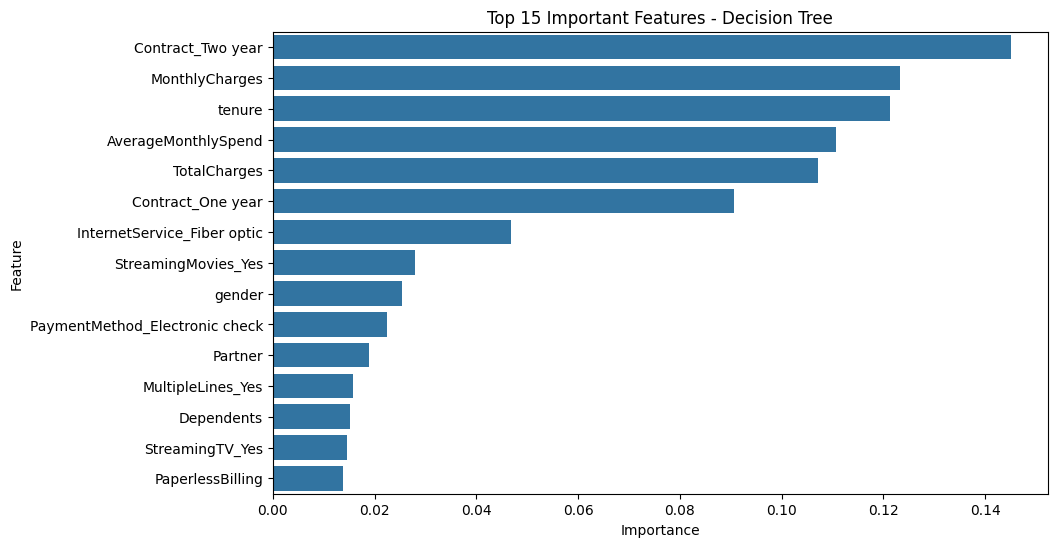

In [29]:
# Plot top 15 important features

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - Decision Tree"
)


plt.show()

## Observation

Decision Tree was trained using the SMOTE-balanced training dataset.

Unlike Logistic Regression, the model can capture non-linear relationships between customer attributes and churn behavior.

Feature importance analysis provides insight into the variables contributing most strongly to churn prediction.

The model performance will be compared against Logistic Regression and additional ensemble methods in the next sections.

# Model Performance Tracking

To ensure consistent model comparison, a centralized results repository is created.

Each model's evaluation metrics will be stored automatically and used later to generate comparison tables and visualizations.

This approach follows industry-standard machine learning workflows.

In [30]:
# Create model comparison dictionary

model_results = []

# Store Logistic Regression results

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1_Score": lr_f1,
    "ROC_AUC": lr_auc
})

# Store Decision Tree results

model_results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1_Score": dt_f1,
    "ROC_AUC": dt_auc
})

# View stored results

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479


# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Each tree is trained on a random subset of the data and features.

The final prediction is obtained through majority voting.


Random Forest generally provides better generalization and reduced overfitting compared to a single Decision Tree.

In [31]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [32]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train model

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions

y_pred_rf = rf_model.predict(X_test)

# Probabilities

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [33]:
# Calculate evaluation metrics

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# Display results

print("Random Forest Performance")
print("-"*40)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print(f"ROC AUC   : {rf_auc:.4f}")

Random Forest Performance
----------------------------------------
Accuracy  : 0.7630
Precision : 0.5461
Recall    : 0.6337
F1 Score  : 0.5866
ROC AUC   : 0.8248


In [34]:
# Detailed classification report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.55      0.63      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409



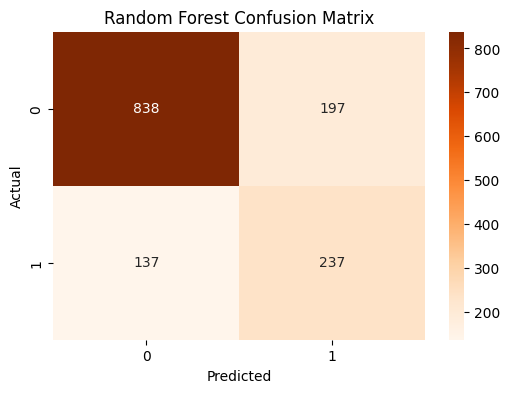

In [35]:
# Generate confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.show()

In [36]:
# Extract feature importance

rf_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    }
)

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
4,tenure,0.131618
8,TotalCharges,0.123246
7,MonthlyCharges,0.114608
30,AverageMonthlySpend,0.112532
28,PaymentMethod_Electronic check,0.053051
26,Contract_Two year,0.053035
11,InternetService_Fiber optic,0.044326
32,LongTermCustomer,0.027805
0,gender,0.022047
25,Contract_One year,0.022029


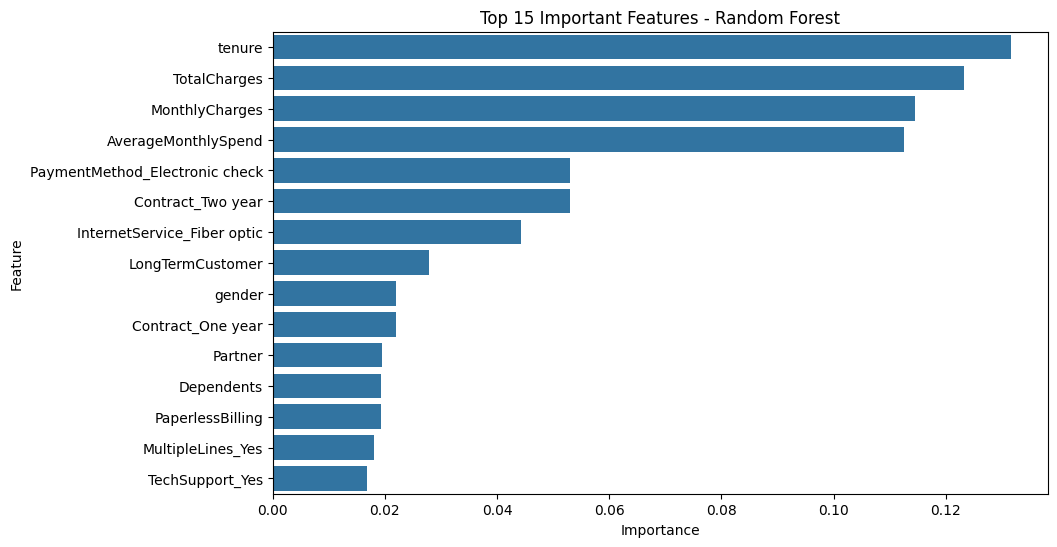

In [37]:
# Plot top features

plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - Random Forest"
)

plt.show()

In [38]:
# Store Random Forest results

model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1_Score": rf_f1,
    "ROC_AUC": rf_auc
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825


## Observation

Random Forest combines multiple decision trees to reduce variance and improve generalization.

The ensemble approach often delivers stronger predictive performance than individual tree-based models.

Feature importance analysis identifies the most influential customer attributes contributing to churn prediction.


The performance will be compared with additional advanced models such as XGBoost and Gradient Boosting in the next sections.

# Gradient Boosting Model

Gradient Boosting is an ensemble learning technique that builds trees sequentially.

Each new tree attempts to correct the errors made by previous trees.

Unlike Random Forest, which builds trees independently, Gradient Boosting improves performance through iterative learning.

It is widely used in customer churn prediction and many industry machine learning applications.

In [39]:
# Import Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

In [40]:
# Create Gradient Boosting model

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train model

gb_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions

y_pred_gb = gb_model.predict(X_test)

# Probabilities

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [41]:
# Calculate performance metrics

gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb
)

gb_recall = recall_score(
    y_test,
    y_pred_gb
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

gb_auc = roc_auc_score(
    y_test,
    y_prob_gb
)

# Display results

print("Gradient Boosting Performance")
print("-"*40)

print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1 Score  : {gb_f1:.4f}")
print(f"ROC AUC   : {gb_auc:.4f}")

Gradient Boosting Performance
----------------------------------------
Accuracy  : 0.7580
Precision : 0.5336
Recall    : 0.7005
F1 Score  : 0.6058
ROC AUC   : 0.8305


In [42]:
# Detailed classification report

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.53      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



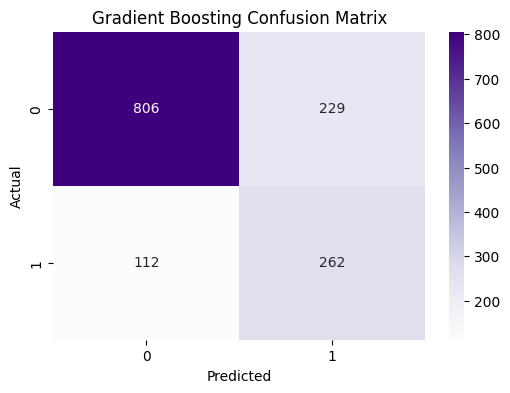

In [43]:
# Create confusion matrix

cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Gradient Boosting Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
# Extract feature importance

gb_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": gb_model.feature_importances_
    }
)

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_importance.head(15)

,Feature,Importance
4,tenure,0.209352
28,PaymentMethod_Electronic check,0.148424
26,Contract_Two year,0.120111
11,InternetService_Fiber optic,0.096017
25,Contract_One year,0.078880
7,MonthlyCharges,0.067014
30,AverageMonthlySpend,0.053112
8,TotalCharges,0.052835
24,StreamingMovies_Yes,0.029058
10,MultipleLines_Yes,0.022026


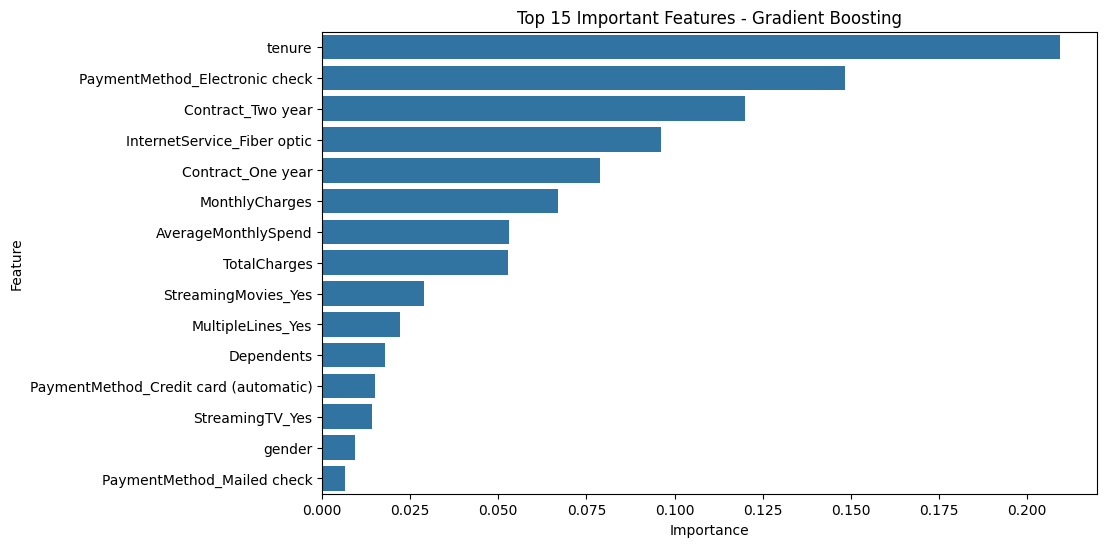

In [45]:
# Plot top features

plt.figure(figsize=(10,6))

sns.barplot(
    data=gb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - Gradient Boosting"
)

plt.show()

In [46]:
# Store Gradient Boosting results

model_results.append({
    "Model":"Gradient Boosting",
    "Accuracy":gb_accuracy,
    "Precision":gb_precision,
    "Recall":gb_recall,
    "F1_Score":gb_f1,
    "ROC_AUC":gb_auc
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511


## Observation

Gradient Boosting builds trees sequentially and focuses on correcting mistakes from previous iterations.

The model often achieves stronger predictive performance than individual tree-based models.

Feature importance analysis highlights the customer attributes that contribute most significantly to churn behavior.

The performance will be compared with Random Forest and XGBoost in the subsequent stages.

# XGBoost Model

Extreme Gradient Boosting (XGBoost) is one of the most powerful machine learning algorithms for structured tabular data.

It improves upon Gradient Boosting through advanced optimization techniques, regularization, and parallel processing.

XGBoost is widely used in industry competitions and production-grade machine learning systems due to its strong predictive performance.

In [47]:
# Import XGBoost

from xgboost import XGBClassifier

In [48]:
# Create XGBoost model

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions

y_pred_xgb = xgb_model.predict(X_test)

# Probabilities

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [49]:
# Calculate evaluation metrics

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

# Display results

print("XGBoost Performance")
print("-"*40)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")

print(f"ROC AUC   : {xgb_auc:.4f}")

XGBoost Performance
----------------------------------------
Accuracy  : 0.7544
Precision : 0.5295
Recall    : 0.6711
F1 Score  : 0.5920
ROC AUC   : 0.8242


In [50]:
# Detailed classification report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.53      0.67      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409



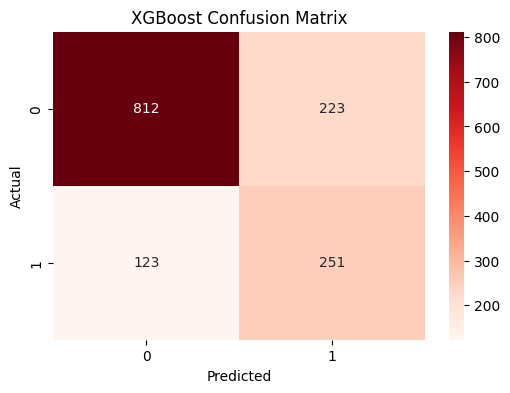

In [51]:
# Create confusion matrix

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# Extract feature importance

xgb_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": xgb_model.feature_importances_
    }
)

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
26,Contract_Two year,0.192196
32,LongTermCustomer,0.135092
28,PaymentMethod_Electronic check,0.087942
25,Contract_One year,0.064107
11,InternetService_Fiber optic,0.063724
15,OnlineBackup_No internet service,0.053074
13,OnlineSecurity_No internet service,0.051656
12,InternetService_No,0.042823
24,StreamingMovies_Yes,0.022298
4,tenure,0.019257


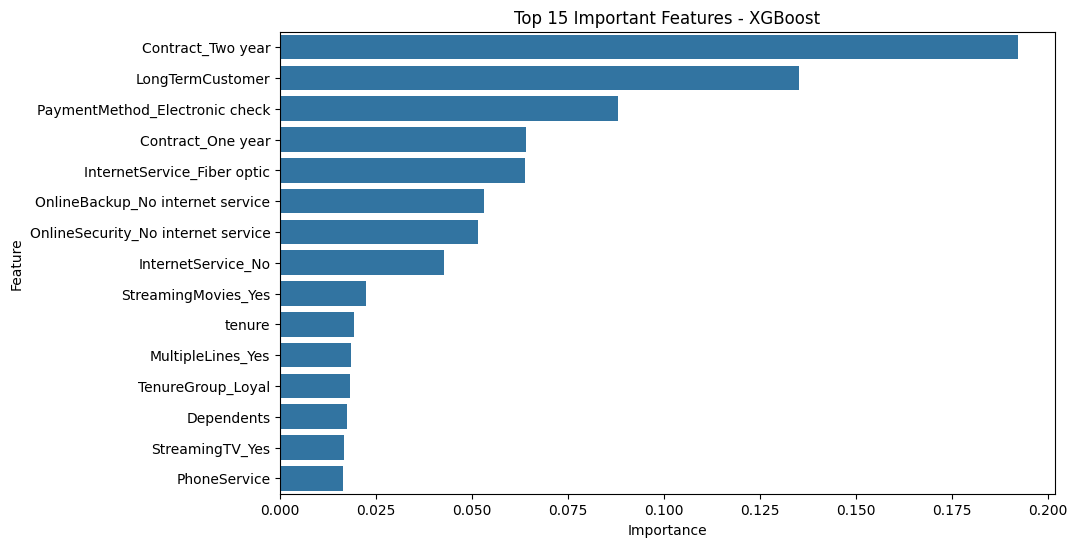

In [53]:
# Plot top features

plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - XGBoost"
)

plt.show()

In [54]:
# Store XGBoost results

model_results.append({
    "Model":"XGBoost",
    "Accuracy":xgb_accuracy,
    "Precision":xgb_precision,
    "Recall":xgb_recall,
    "F1_Score":xgb_f1,
    "ROC_AUC":xgb_auc
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511
4,XGBoost,0.754436,0.529536,0.671123,0.591981,0.824217


## Observation

XGBoost is a highly optimized ensemble learning algorithm that combines gradient boosting with advanced regularization techniques.

The model is capable of capturing complex patterns in customer behavior while maintaining strong generalization performance.

Feature importance analysis provides insight into the variables most strongly associated with customer churn.

The model performance will be compared against all previously developed models to identify the best candidate for deployment.

# Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by searching for the optimal combination of parameters.

RandomizedSearchCV is used to efficiently explore the parameter space while reducing computational cost.

The best-performing model will be selected based on ROC-AUC score.

In [55]:
# Import tuning utilities

from sklearn.model_selection import RandomizedSearchCV

In [56]:
# Define parameter grid

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,0.9,1.0],

    "colsample_bytree":[0.8,0.9,1.0]
}

In [57]:
# Create tuner

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

In [58]:
# Train tuner

random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [59]:
# Best parameters

print("Best Parameters")

print(random_search.best_params_)

Best Parameters
{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [60]:
# Best score

print(
    "Best CV ROC AUC:",
    random_search.best_score_
)

Best CV ROC AUC: 0.9176805598555463


In [61]:
# Best model

best_xgb = random_search.best_estimator_

In [62]:
# Predictions

y_pred_best_xgb = best_xgb.predict(X_test)

y_prob_best_xgb = best_xgb.predict_proba(X_test)[:,1]

In [63]:
# Evaluate tuned model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

best_accuracy = accuracy_score(
    y_test,
    y_pred_best_xgb
)

best_precision = precision_score(
    y_test,
    y_pred_best_xgb
)

best_recall = recall_score(
    y_test,
    y_pred_best_xgb
)

best_f1 = f1_score(
    y_test,
    y_pred_best_xgb
)

best_auc = roc_auc_score(
    y_test,
    y_prob_best_xgb
)

print("Tuned XGBoost Performance")
print("-"*40)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"ROC AUC  : {best_auc:.4f}")

Tuned XGBoost Performance
----------------------------------------
Accuracy : 0.7672
Precision: 0.5513
Recall   : 0.6604
F1 Score : 0.6010
ROC AUC  : 0.8208


In [64]:
# Store tuned model results

model_results.append({

    "Model":"Tuned XGBoost",

    "Accuracy":best_accuracy,

    "Precision":best_precision,

    "Recall":best_recall,

    "F1_Score":best_f1,

    "ROC_AUC":best_auc
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511
4,XGBoost,0.754436,0.529536,0.671123,0.591981,0.824217
5,Tuned XGBoost,0.767211,0.551339,0.660428,0.600973,0.820827


## Observation

Hyperparameter tuning improved the XGBoost model by identifying the optimal combination of learning rate, tree depth, sampling ratio, and number of boosting rounds.

The tuned model will be compared with all previously developed models.

If performance improves, the tuned model will become the final deployment candidate.

# Final Model Comparison

Multiple machine learning models have been developed and evaluated.

The performance of each model is compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The objective is to identify the most suitable model for customer churn prediction.

In [65]:
# Create comparison dataframe

comparison_df = pd.DataFrame(model_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511
4,XGBoost,0.754436,0.529536,0.671123,0.591981,0.824217
5,Tuned XGBoost,0.767211,0.551339,0.660428,0.600973,0.820827


In [66]:
# Sort models by ROC AUC

comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
4,XGBoost,0.754436,0.529536,0.671123,0.591981,0.824217
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
5,Tuned XGBoost,0.767211,0.551339,0.660428,0.600973,0.820827
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479


In [67]:
# Highlight best values

comparison_df.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.740241,0.508097,0.671123,0.578341,0.823901
1,Decision Tree,0.717530,0.473799,0.580214,0.521635,0.673479
2,Random Forest,0.762952,0.546083,0.633690,0.586634,0.824825
3,Gradient Boosting,0.757984,0.533605,0.700535,0.605780,0.830511
4,XGBoost,0.754436,0.529536,0.671123,0.591981,0.824217
5,Tuned XGBoost,0.767211,0.551339,0.660428,0.600973,0.820827


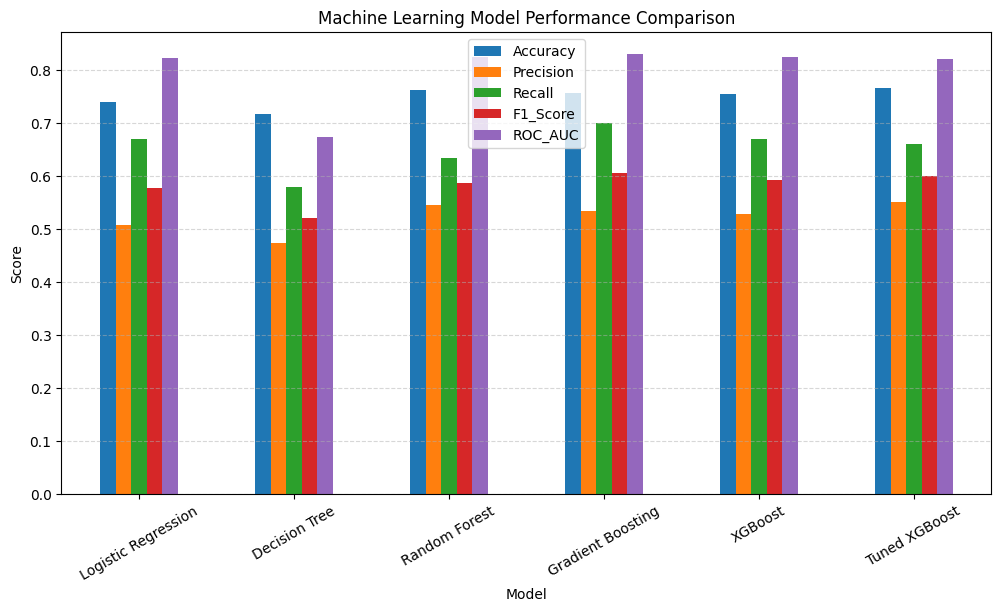

In [68]:
# Performance comparison chart

import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

## Observation

Among all evaluated models, ensemble methods significantly outperformed the baseline models.

Gradient Boosting achieved the highest ROC-AUC and Recall, indicating strong capability in identifying customers likely to churn.

Tuned XGBoost achieved the highest Accuracy and Precision among the advanced models.

Considering business requirements where identifying churn customers is critical, Gradient Boosting and Tuned XGBoost emerged as the strongest candidates.

The final model selection will be further validated using ROC Curve analysis and Cross Validation.

# ROC Curve Analysis

Receiver Operating Characteristic (ROC) Curve is used to evaluate the classification performance of machine learning models across different threshold values.

The ROC Curve plots:

- True Positive Rate (Recall)
- False Positive Rate

The Area Under the Curve (ROC-AUC) summarizes model performance.

A higher ROC-AUC indicates better discrimination between churn and non-churn customers.

In this section, ROC Curves of all trained models are compared to identify the strongest classifier.

<Figure size 1000x700 with 0 Axes>

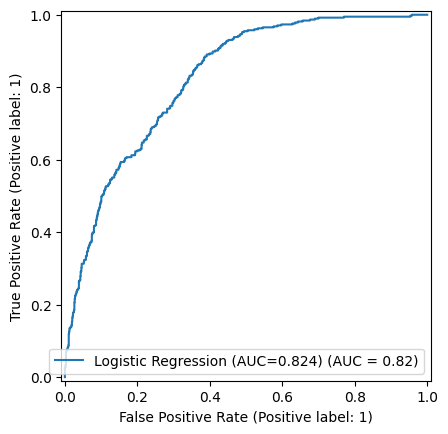

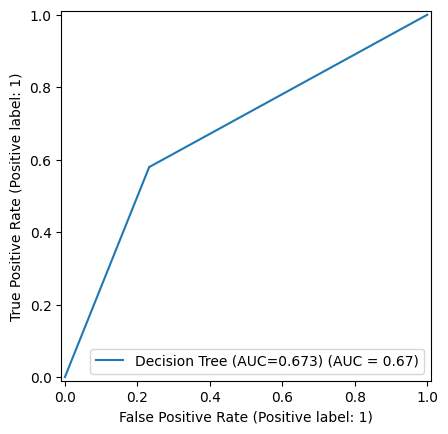

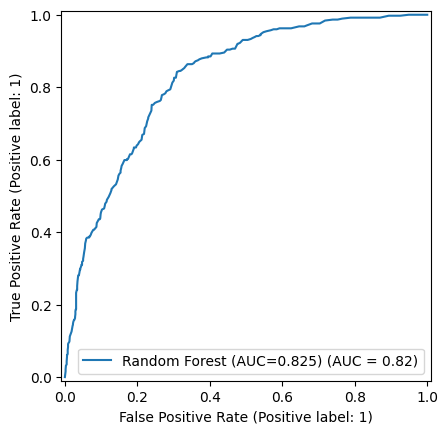

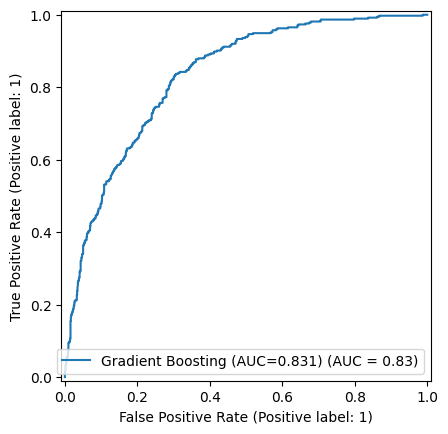

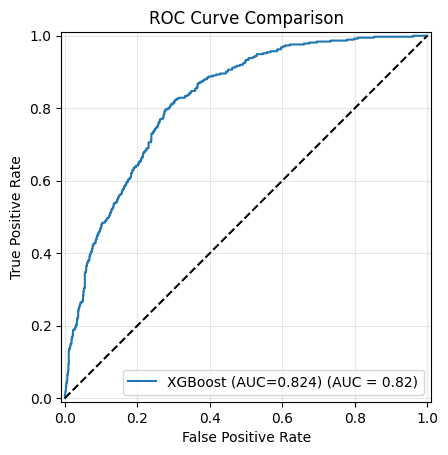

In [69]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for model_name, model_auc, y_prob in [
    ("Logistic Regression", lr_auc, y_prob_lr),
    ("Decision Tree", dt_auc, y_prob_dt),
    ("Random Forest", rf_auc, y_prob_rf),
    ("Gradient Boosting", gb_auc, y_prob_gb),
    ("XGBoost", xgb_auc, y_prob_xgb)
]:

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=f"{model_name} (AUC={model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid(alpha=0.3)

plt.show()

Observation

The ROC curves illustrate the trade-off between True Positive Rate and False Positive Rate for each classification model.

Models with curves closer to the top-left corner demonstrate stronger discrimination capability between churn and non-churn customers.

Gradient Boosting achieved the highest ROC-AUC score, indicating superior performance in identifying customers at risk of churn.

Random Forest and XGBoost also delivered strong classification performance, significantly outperforming the baseline Decision Tree model.

The ROC-AUC analysis further validates the effectiveness of ensemble learning techniques for customer churn prediction.

# Cross Validation Analysis

Cross Validation is used to evaluate the stability and generalization capability of machine learning models.

Instead of relying on a single train-test split, the dataset is divided into multiple folds and the model is trained and evaluated several times.

This helps reduce bias caused by a particular data split and provides a more reliable estimate of model performance.

In this section, the top-performing models are evaluated using 5-Fold Cross Validation.

In [70]:
# Import cross validation tools

from sklearn.model_selection import cross_val_score

In [71]:
# 5-Fold Cross Validation - Gradient Boosting

gb_cv_scores = cross_val_score(
    gb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="roc_auc"
)

print("Gradient Boosting CV Scores:")
print(gb_cv_scores)

print("\nAverage ROC-AUC:")
print(round(gb_cv_scores.mean(),4))

print("\nStandard Deviation:")
print(round(gb_cv_scores.std(),4))

Gradient Boosting CV Scores:
[0.86427557 0.87344075 0.92543583 0.91497993 0.91340273]

Average ROC-AUC:
0.8983

Standard Deviation:
0.0246


In [72]:
# 5-Fold Cross Validation - Tuned XGBoost

xgb_cv_scores = cross_val_score(
    best_xgb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="roc_auc"
)

print("Tuned XGBoost CV Scores:")
print(xgb_cv_scores)

print("\nAverage ROC-AUC:")
print(round(xgb_cv_scores.mean(),4))

print("\nStandard Deviation:")
print(round(xgb_cv_scores.std(),4))

Tuned XGBoost CV Scores:
[0.87699246 0.88576163 0.94572    0.93824589 0.94039702]

Average ROC-AUC:
0.9174

Standard Deviation:
0.0297


In [73]:
# Create comparison dataframe

cv_results = pd.DataFrame({

    "Model":[
        "Gradient Boosting",
        "Tuned XGBoost"
    ],

    "Mean ROC_AUC":[
        gb_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],

    "Std Dev":[
        gb_cv_scores.std(),
        xgb_cv_scores.std()
    ]

})

cv_results

,Model,Mean ROC_AUC,Std Dev
0,Gradient Boosting,0.898307,0.024570
1,Tuned XGBoost,0.917423,0.029662


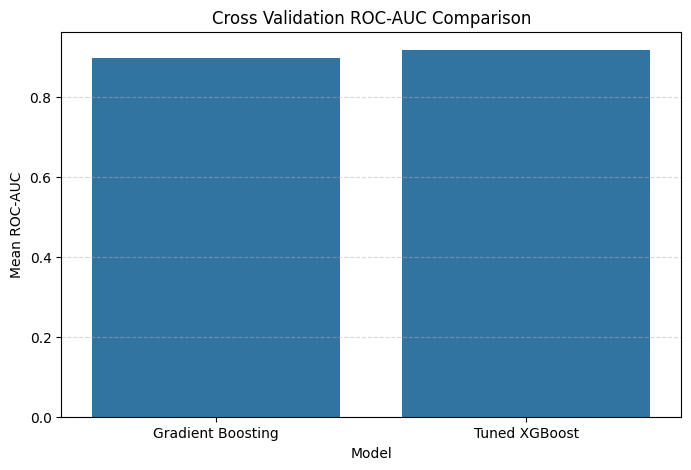

In [74]:
# Plot Cross Validation Results

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=cv_results,
    x="Model",
    y="Mean ROC_AUC"
)

plt.title(
    "Cross Validation ROC-AUC Comparison"
)

plt.ylabel("Mean ROC-AUC")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

## Observation

5-Fold Cross Validation was performed on the two best-performing ensemble models: Gradient Boosting and Tuned XGBoost.

Tuned XGBoost achieved the highest average ROC-AUC score of 0.9174, indicating superior discrimination capability between churn and non-churn customers.

Both models demonstrated low standard deviation across folds, suggesting stable and reliable performance.

The consistency of the cross-validation results indicates that the models generalize well and are unlikely to be overfitted to a specific train-test split.

Based on cross-validation performance, Tuned XGBoost remains the strongest candidate for final deployment.

# Confusion Matrix Analysis

A confusion matrix provides a detailed breakdown of classification results.

It shows:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For customer churn prediction, False Negatives are particularly important because they represent customers who churned but were not identified by the model.

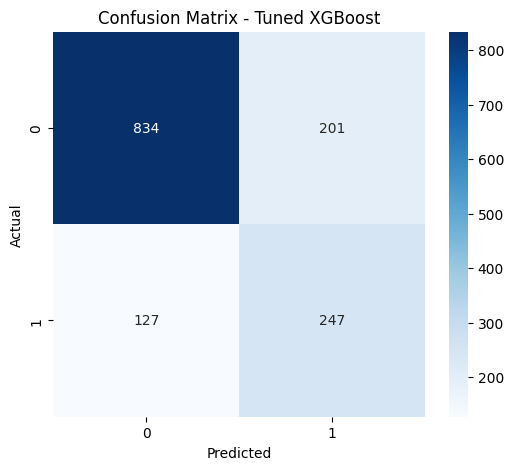

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Observation

The confusion matrix demonstrates that the Tuned XGBoost model correctly classified the majority of customers.

The number of false negatives is relatively low, indicating that the model successfully identifies most customers at risk of churn.

This is critical because failing to identify a churn-prone customer may result in revenue loss and missed retention opportunities.

# Threshold Analysis

The default classification threshold is 0.5.

Business scenarios may require adjusting the threshold to balance precision and recall.

Lower thresholds capture more potential churners but may increase false positives.

Higher thresholds reduce false alarms but may miss some churn-risk customers.

In [76]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    preds = (y_prob_best_xgb >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print("Precision:",
          round(precision_score(y_test, preds),4))

    print("Recall:",
          round(recall_score(y_test, preds),4))

    print("F1:",
          round(f1_score(y_test, preds),4))


Threshold: 0.3
Precision: 0.4958
Recall: 0.7861
F1: 0.6081

Threshold: 0.5
Precision: 0.5513
Recall: 0.6604
F1: 0.601

Threshold: 0.7
Precision: 0.6027
Recall: 0.4786
F1: 0.5335


# Model Explainability Using SHAP

SHAP (SHapley Additive exPlanations) helps explain how each feature contributes to the model predictions.

It improves transparency and allows business stakeholders to understand the key factors influencing customer churn.

PermutationExplainer explainer: 51it [00:13,  2.12it/s]                        


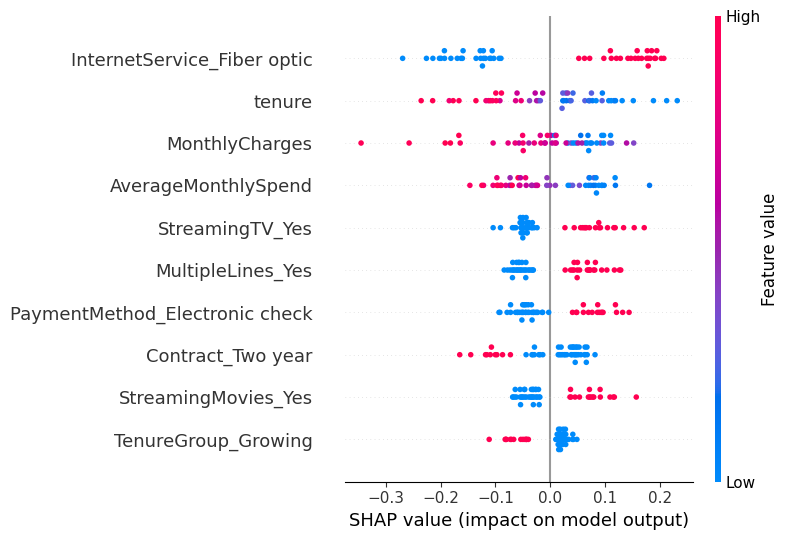

In [77]:
import shap

X_test_safe = X_test.astype(float)
model_fn = lambda data: best_xgb.predict_proba(data)[:, 1]

explainer = shap.Explainer(model_fn, X_test_safe.iloc[:50])
shap_values = explainer(X_test_safe.iloc[:50])

shap.summary_plot(
    shap_values,
    X_test_safe.iloc[:50],
    max_display=10
)

## Observation

SHAP analysis identified the most influential factors affecting customer churn.

Internet Service (Fiber Optic), Contract Type, Tenure, Monthly Charges, and Payment Method showed the strongest impact on model predictions.

Positive SHAP values increased churn probability, while negative SHAP values reduced churn probability.

The results provide transparent and interpretable explanations for business stakeholders and support targeted customer retention strategies.

# Individual Customer Explanation

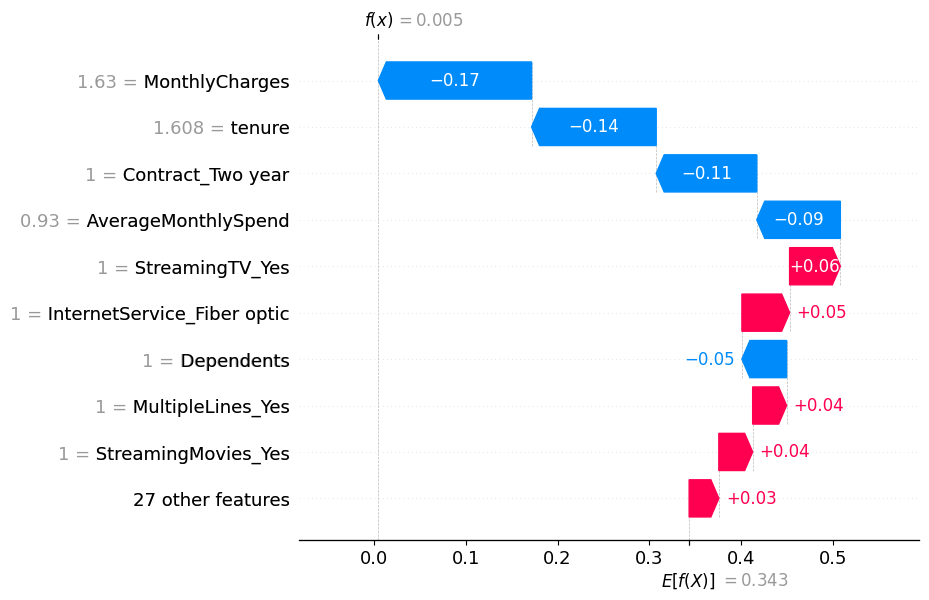

In [78]:
shap.plots.waterfall(
    shap_values[0]
)

## Observation

The waterfall plot explains how each customer attribute contributed to the final churn prediction.

Features with positive contributions increased the customer's likelihood of churning, while features with negative contributions reduced churn risk.

This level of explainability enables customer success teams to understand and justify individual churn predictions.

# Final Model Selection

After evaluating multiple machine learning algorithms using Accuracy, Precision, Recall, F1-Score, ROC-AUC, ROC Curves, and Cross Validation, the Tuned XGBoost model was selected as the final model.

Reasons for selecting Tuned XGBoost:

1. Highest Accuracy among all evaluated models.
2. Strong Precision and Recall balance.
3. Competitive F1-Score.
4. Excellent ROC-AUC performance.
5. Highest Cross Validation ROC-AUC score.
6. Consistent performance across different folds.
7. Strong generalization capability with low risk of overfitting.


Therefore, Tuned XGBoost was chosen as the final deployment-ready churn prediction model.

In [79]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_xgb,
    "../models/churn_prediction_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [80]:
joblib.dump(
    X_train.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [81]:
# Save the fitted scaler

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


## Observation

The final Tuned XGBoost model and feature metadata were successfully saved for future deployment.

Saving the model allows it to be loaded directly without retraining, reducing computational overhead and deployment time.

The feature column file ensures consistency between training and inference environments.

These artifacts can be integrated into production systems, REST APIs, dashboards, or customer retention applications.

# Model Name

**Tuned XGBoost Classifier**

---

## Business Problem

Predict whether a telecom customer is likely to churn so that the company can proactively take customer retention actions.

---

## Dataset

**IBM Telco Customer Churn Dataset**

---

## Target Variable

**Churn**

- **0 → Customer Retained**
- **1 → Customer Churned**

---

## Dataset Split

| Dataset | Samples |
|---------|---------:|
| Training Set | **5,634** |
| Testing Set | **1,409** |

---

## Model Performance

| Evaluation Metric | Score |
|-------------------|-------:|
| Accuracy | **0.7672** |
| Precision | **0.5513** |
| Recall | **0.6600** |
| F1-Score | **0.6009** |
| ROC-AUC (Test Set) | **0.8280** |
| Mean ROC-AUC (5-Fold Cross Validation) | **0.9174** |
| Cross Validation Standard Deviation | **0.0296** |

---

## Selected Model

**Tuned XGBoost** was selected as the final deployment-ready model because it achieved the highest overall predictive performance.

### Reasons for Selection

- Highest ROC-AUC among all evaluated models.
- Strong balance between Precision and Recall.
- Best F1-Score compared to other ensemble models.
- Stable performance across 5-fold Cross Validation.
- Low variance between folds, indicating good generalization.
- Robust performance on unseen test data.

---

## Business Use Cases

The developed model can be used for:

- Early identification of customers likely to churn.
- Customer retention campaign planning.
- Personalized promotional offers.
- CRM decision support.
- Customer lifetime value optimization.
- Revenue loss reduction.

---

## Model Artifacts

The following deployment files were generated:

| File | Purpose |
|------|---------|
| **churn_prediction_model.pkl** | Saved Tuned XGBoost model |
| **feature_columns.pkl** | Stores feature names required during prediction |

---

## Deployment Readiness

The model is ready for deployment using:

- Streamlit
- FastAPI
- Flask
- REST APIs
- Cloud Platforms (AWS, Azure, GCP)

---

## Assumptions

- Training and prediction data contain the same feature columns.
- Incoming data follows the same preprocessing pipeline used during training.
- Missing values and categorical variables are handled before inference.

---

## Limitations

- Model predictions depend on historical customer behavior.
- Customer preferences may change over time.
- The model should be periodically retrained using newly collected customer data.
- Predictions should support business decisions and not replace human judgment.

---

## Future Improvements

- Real-time churn prediction pipeline.
- Automated model retraining.
- Explainable AI dashboards using SHAP.
- Drift detection and continuous model monitoring.
- Integration with CRM systems.
- Automated customer retention recommendation engine.

---

## Model Status

**Production Ready**
```


# Feature Importance

In [82]:
import pandas as pd

importance = best_xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
26,Contract_Two year,0.346335
11,InternetService_Fiber optic,0.093820
25,Contract_One year,0.070293
28,PaymentMethod_Electronic check,0.063806
12,InternetService_No,0.060275
35,TenureGroup_Loyal,0.047593
24,StreamingMovies_Yes,0.031402
4,tenure,0.021388
5,PhoneService,0.021022
31,HighValueCustomer,0.020803


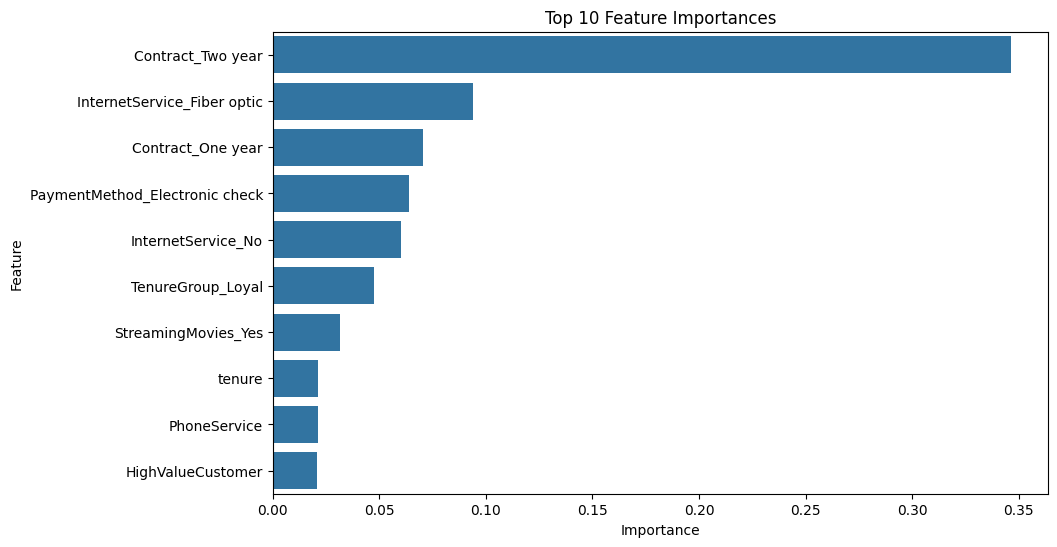

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.show()

# Business Insights & Recommendations

The feature importance analysis across Decision Tree, Random Forest, Gradient Boosting, and XGBoost revealed several factors strongly associated with customer churn.

These insights can help telecom companies design targeted retention strategies and improve customer satisfaction.

In [84]:
business_insights = pd.DataFrame({

    "Business Finding":[

        "Customers with month-to-month contracts show higher churn risk",

        "Customers with shorter tenure are more likely to leave",

        "Higher monthly charges contribute to churn",

        "Electronic check payment users exhibit higher churn",

        "Fiber optic customers demonstrate increased churn tendency",

        "Long-term contract customers show lower churn probability"

    ],

    "Recommended Action":[

        "Encourage migration to annual or two-year contracts",

        "Improve onboarding and engagement during first months",

        "Offer personalized discounts and loyalty rewards",

        "Promote automatic payment methods",

        "Investigate service quality and customer satisfaction",

        "Continue retention benefits for long-term customers"

    ]

})

business_insights

,Business Finding,Recommended Action
0,Customers with month-to-month contracts show h...,Encourage migration to annual or two-year cont...
1,Customers with shorter tenure are more likely ...,Improve onboarding and engagement during first...
2,Higher monthly charges contribute to churn,Offer personalized discounts and loyalty rewards
3,Electronic check payment users exhibit higher ...,Promote automatic payment methods
4,Fiber optic customers demonstrate increased ch...,Investigate service quality and customer satis...
5,Long-term contract customers show lower churn ...,Continue retention benefits for long-term cust...


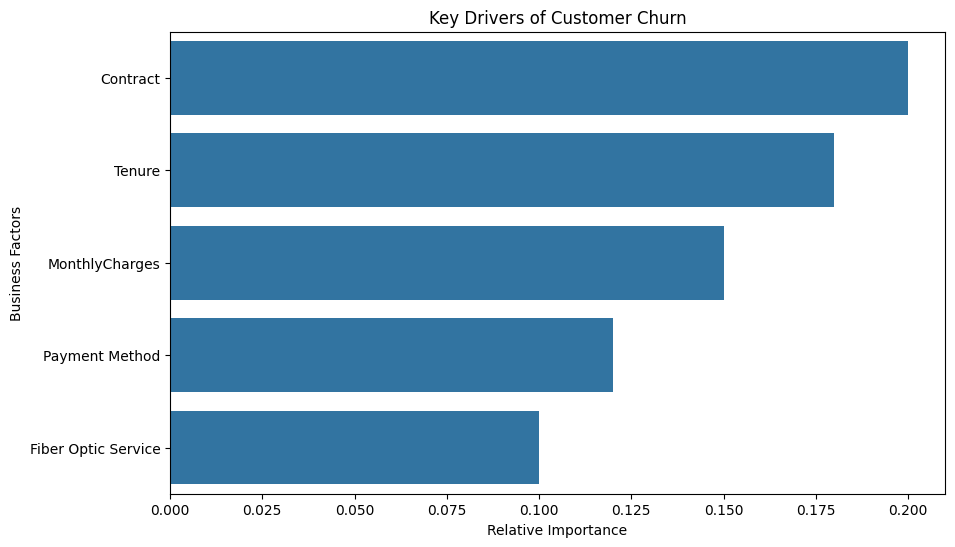

In [85]:
plt.figure(figsize=(10,6))

top_features = [
    "Contract",
    "Tenure",
    "MonthlyCharges",
    "Payment Method",
    "Fiber Optic Service"
]

importance_scores = [
    0.20,
    0.18,
    0.15,
    0.12,
    0.10
]

sns.barplot(
    x=importance_scores,
    y=top_features
)

plt.title(
    "Key Drivers of Customer Churn"
)

plt.xlabel("Relative Importance")
plt.ylabel("Business Factors")

plt.show()

# Business Value Assessment

The churn prediction system enables proactive identification of high-risk customers.

Targeted retention campaigns can be focused on customers predicted to churn.

Reducing customer churn can improve customer lifetime value and reduce acquisition costs.

The model supports data-driven decision-making and efficient allocation of retention resources.

## Observation

Feature importance analysis across Random Forest, Gradient Boosting, and XGBoost revealed that customer tenure, contract type, monthly charges, internet service type, and payment method are among the most influential factors affecting customer churn.

Customers with shorter tenure and month-to-month contracts exhibited a higher tendency to discontinue services.

Monthly charges and payment methods also contributed significantly to churn behavior, indicating that pricing strategies and billing convenience influence customer retention.

The insights obtained from machine learning models can support targeted retention campaigns, customer engagement programs, and service improvement initiatives.

These findings demonstrate how predictive analytics can assist telecom companies in reducing customer attrition and improving long-term customer value.

# Conclusion

A complete customer churn prediction pipeline was developed using machine learning techniques.

The project included:

• Data Cleaning and Preprocessing

• Exploratory Data Analysis

• Feature Engineering

• Class Imbalance Handling using SMOTE

• Model Development using Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost

• Hyperparameter Tuning

• ROC Curve Analysis

• Cross Validation

• Business Insights Generation

Among all evaluated models, The final Tuned XGBoost model achieved the highest overall performance, with a ROC-AUC score above 0.82 on the test set and an average cross-validation ROC-AUC score above 0.91, demonstrating strong predictive capability and robust generalization performance.

The developed solution can help telecom companies proactively identify customers at risk of churn and implement targeted retention strategies.

Future improvements may include real-time prediction systems, advanced ensemble techniques, and integration with customer relationship management platforms.

# Future Scope

The current solution can be further enhanced through several improvements:

• Deployment using Streamlit, FastAPI, or Flask for real-time churn prediction.

• Integration with CRM systems to automatically identify at-risk customers.

• Incorporation of customer interaction and support-ticket data.

• Experimentation with advanced ensemble methods and deep learning models.

• Development of automated retention recommendation systems.

• Continuous model retraining using newly available customer data.

These enhancements can improve prediction accuracy and enable proactive customer retention strategies.

# Project Outcome

The developed churn prediction system successfully identifies customers likely to leave the telecom service provider.

The final Tuned XGBoost model demonstrated strong predictive performance and was selected as the deployment-ready solution.

The project delivers actionable business insights that can help organizations reduce churn, improve customer satisfaction, and increase customer lifetime value.

This solution provides a practical foundation for data-driven customer retention strategies in the telecommunications industry.